# SentinelAI V1 — Exploratory Data Analysis

Dataset: UCI SMS Spam Collection

Purpose:
- understand corpus characteristics
- quantify class imbalance
- inspect message structure
- identify duplicate and normalization patterns
- derive explicit preprocessing decisions for Phase 3

This notebook is exploratory only. Nothing in the shipped inference pipeline imports this notebook.


In [2]:
rows = []

with DATASET_PATH.open("r", encoding="utf-8") as file:
    for line_number, line in enumerate(file, start=1):
        label, message = line.rstrip("\n").split("\t", maxsplit=1)

        rows.append({
            "row_number": line_number,
            "label": label,
            "message": message,
        })

df = pd.DataFrame(rows)

print(f"Loaded {len(df):,} messages")
df.head()

Loaded 5,574 messages


,row_number,label,message
0,1,ham,"Go until jurong point, crazy.. Available only ..."
1,2,ham,Ok lar... Joking wif u oni...
2,3,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,4,ham,U dun say so early hor... U c already then say...
4,5,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()


## 1. Class Balance


Counts:
label
ham     4827
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.5985
spam    13.4015
Name: count, dtype: float64


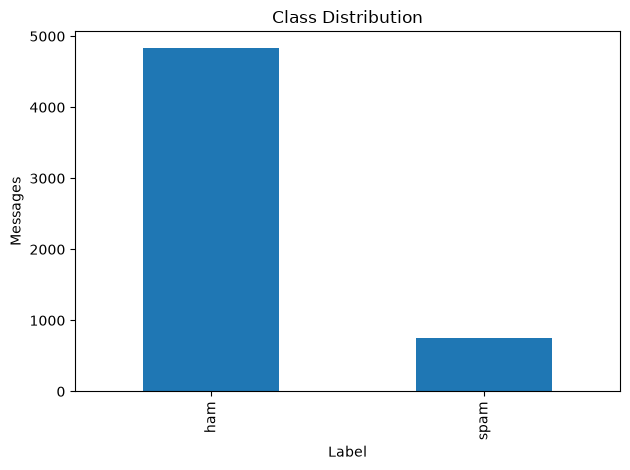

In [3]:
class_counts = df["label"].value_counts()
class_percentages = (class_counts / len(df) * 100).round(4)

print("Counts:")
print(class_counts)

print("\nPercentages:")
print(class_percentages)

ax = class_counts.plot.bar()
ax.set_title("Class Distribution")
ax.set_xlabel("Label")
ax.set_ylabel("Messages")
plt.tight_layout()
plt.show()


## 2. Message Length


In [4]:
df["char_length"] = df["message"].str.len()
df["word_length"] = df["message"].str.split().str.len()

print(df.groupby("label")[["char_length", "word_length"]].agg(
    ["count", "mean", "median", "min", "max"]
))


      char_length                             word_length                    \
            count        mean median min  max       count       mean median   
label                                                                         
ham          4827   71.471929   52.0   2  910        4827  14.304123   11.0   
spam          747  138.676037  149.0  13  223         747  23.911647   25.0   

                
      min  max  
label           
ham     1  171  
spam    2   35  


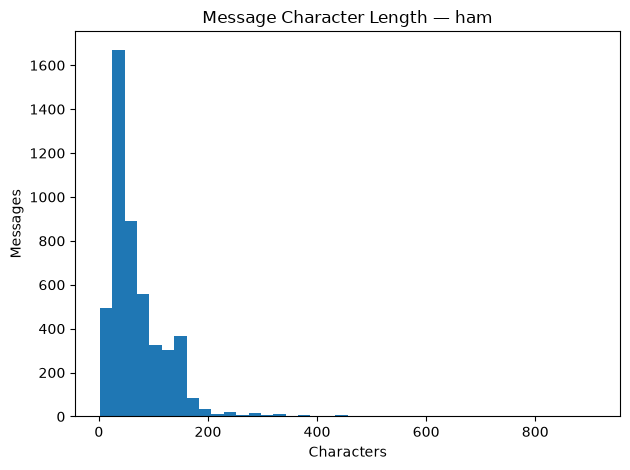

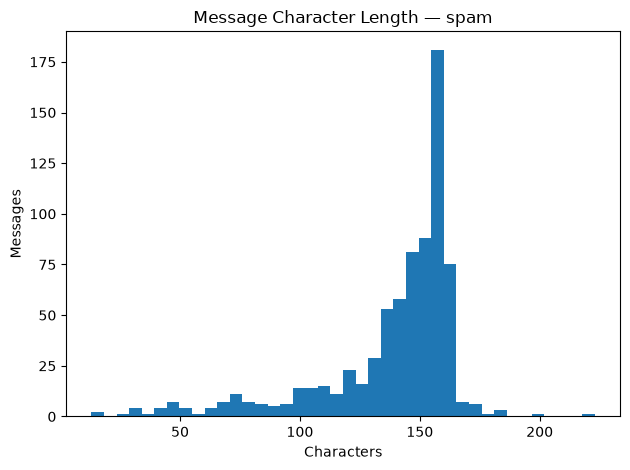

In [5]:
for label in ["ham", "spam"]:
    subset = df.loc[df["label"] == label, "char_length"]

    plt.figure()
    plt.hist(subset, bins=40)
    plt.title(f"Message Character Length — {label}")
    plt.xlabel("Characters")
    plt.ylabel("Messages")
    plt.tight_layout()
    plt.show()


In [6]:
length_summary = (
    df.groupby("label")["char_length"]
    .describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])
)

length_summary


,count,mean,std,min,25%,50%,75%,95%,99%,max
label,,,,,,,,,,
ham,4827.0,71.471929,58.326643,2.0,33.0,52.0,93.0,159.0,288.48,910.0
spam,747.0,138.676037,28.871250,13.0,133.0,149.0,157.0,162.0,174.08,223.0


## 3. Raw Token Frequency by Class

Tokenization here is deliberately simple and exploratory. This is **not** the final preprocessing implementation.


In [7]:
TOKEN_PATTERN = re.compile(r"[A-Za-z0-9']+")

def raw_tokens(text: str) -> list[str]:
    return TOKEN_PATTERN.findall(text.lower())

for label in ["ham", "spam"]:
    counter = Counter()

    for message in df.loc[df["label"] == label, "message"]:
        counter.update(raw_tokens(message))

    print(f"\nTop 30 tokens — {label}")
    print(counter.most_common(30))



Top 30 tokens — ham
[('i', 2331), ('you', 1866), ('to', 1562), ('the', 1133), ('a', 1070), ('u', 1019), ('and', 858), ('in', 823), ('me', 777), ('my', 754), ('is', 738), ('it', 623), ('of', 526), ('for', 507), ('that', 500), ('have', 443), ('but', 441), ('so', 436), ('not', 421), ('your', 416), ('are', 415), ('on', 393), ("i'm", 386), ('do', 385), ('can', 381), ('at', 380), ('if', 357), ('will', 346), ('be', 336), ('2', 326)]

Top 30 tokens — spam
[('to', 691), ('a', 380), ('call', 355), ('you', 290), ('your', 264), ('free', 224), ('2', 207), ('the', 206), ('for', 204), ('now', 202), ('or', 188), ('u', 169), ('txt', 163), ('is', 158), ('on', 145), ('ur', 144), ('4', 137), ('have', 135), ('from', 131), ('mobile', 127), ('text', 125), ('stop', 123), ('and', 122), ('claim', 113), ('1', 112), ('with', 109), ('reply', 104), ('www', 98), ('of', 97), ('prize', 93)]


## 4. Duplicate and Normalized-Duplicate Analysis

Phase 1 identified 403 exact duplicate rows.

Here we also inspect duplicates after a conservative normalization used **only for analysis**.


In [8]:
df["normalized_analysis"] = (
    df["message"]
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

exact_duplicate_count = len(df) - df[["label", "message"]].drop_duplicates().shape[0]
normalized_duplicate_count = (
    len(df) - df[["label", "normalized_analysis"]].drop_duplicates().shape[0]
)

print("Exact duplicate rows:", exact_duplicate_count)
print("Normalized duplicate rows:", normalized_duplicate_count)

normalized_groups = (
    df.groupby(["label", "normalized_analysis"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

normalized_groups.head(20)


Exact duplicate rows: 403
Normalized duplicate rows: 415


,label,normalized_analysis,count
3409,ham,"sorry, i'll call later",30
1582,ham,i cant pick the phone right now. pls send a me...,12
2967,ham,ok...,10
108,ham,7 wonders in my world 7th you 6th ur style 5th...,4
2868,ham,ok,4
3986,ham,"wen ur lovable bcums angry wid u, dnt take it ...",4
3216,ham,"say this slowly.? god,i love you &amp; i need ...",4
2996,ham,okie,4
4851,spam,please call our customer service representativ...,4
4444,ham,your opinion about me? 1. over 2. jada 3. kusr...,4


## 5. Punctuation, Digits, and Uppercase Density


In [9]:
def safe_ratio(numerator: int, denominator: int) -> float:
    return numerator / denominator if denominator else 0.0


df["punctuation_density"] = df["message"].map(
    lambda text: safe_ratio(
        sum(not character.isalnum() and not character.isspace() for character in text),
        len(text),
    )
)

df["digit_density"] = df["message"].map(
    lambda text: safe_ratio(
        sum(character.isdigit() for character in text),
        len(text),
    )
)

df["uppercase_density"] = df["message"].map(
    lambda text: safe_ratio(
        sum(character.isupper() for character in text),
        sum(character.isalpha() for character in text),
    )
)

df["non_ascii_count"] = df["message"].map(
    lambda text: sum(ord(character) > 127 for character in text)
)

density_summary = df.groupby("label")[
    [
        "punctuation_density",
        "digit_density",
        "uppercase_density",
        "non_ascii_count",
    ]
].agg(
    ["mean", "median", "min", "max"]
)

density_summary


punctuation_density                          digit_density            \
                     mean    median  min       max          mean    median   
label                                                                        
ham              0.062240  0.046512  0.0  0.857143      0.004239  0.000000   
spam             0.044174  0.042254  0.0  0.175182      0.116530  0.117284   

                     uppercase_density                     non_ascii_count  \
       min       max              mean    median  min  max            mean   
label                                                                        
ham    0.0  1.000000          0.079004  0.045455  0.0  1.0        0.062358   
spam   0.0  0.615385          0.167310  0.148148  0.0  1.0        0.444444   

                      
      median min max  
label                 
ham      0.0   0   4  
spam     0.0   0   4

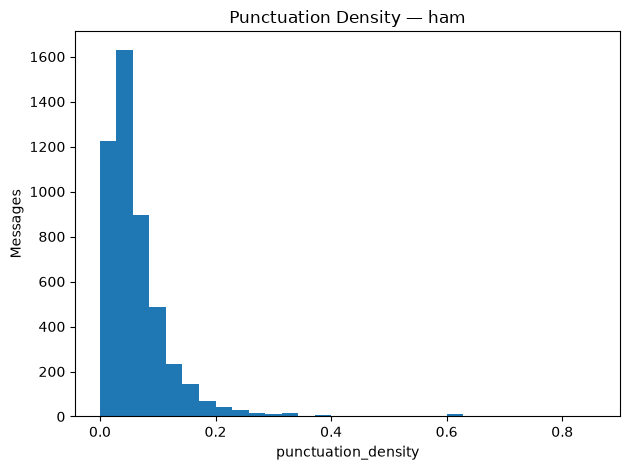

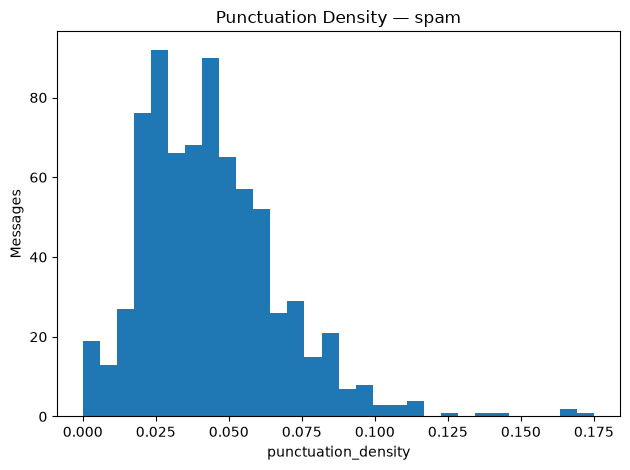

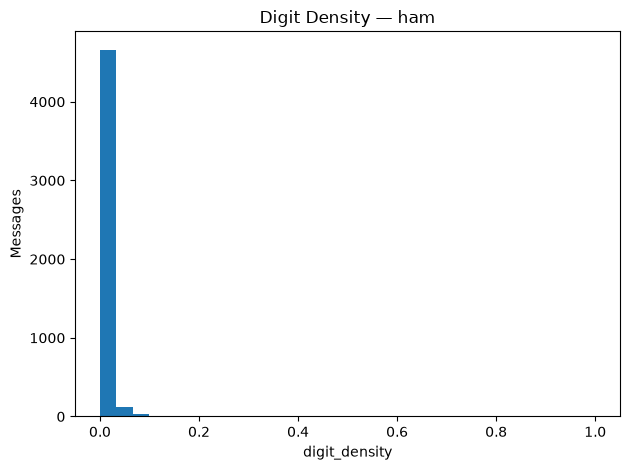

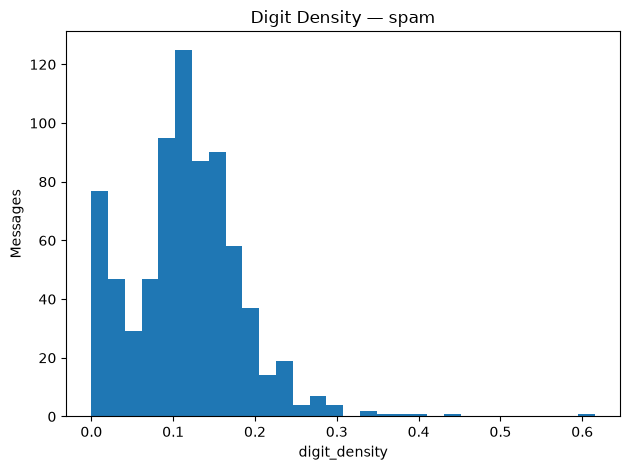

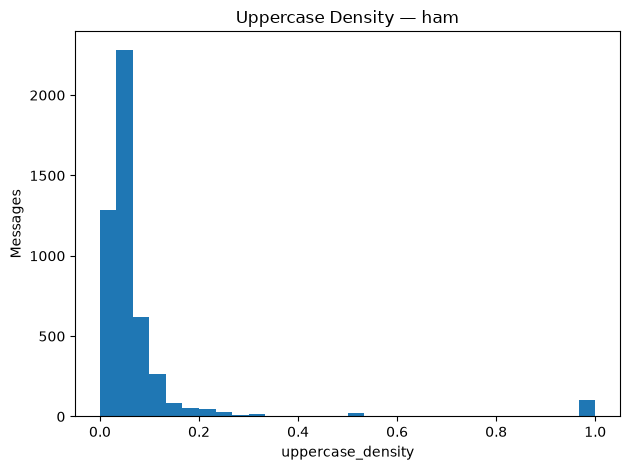

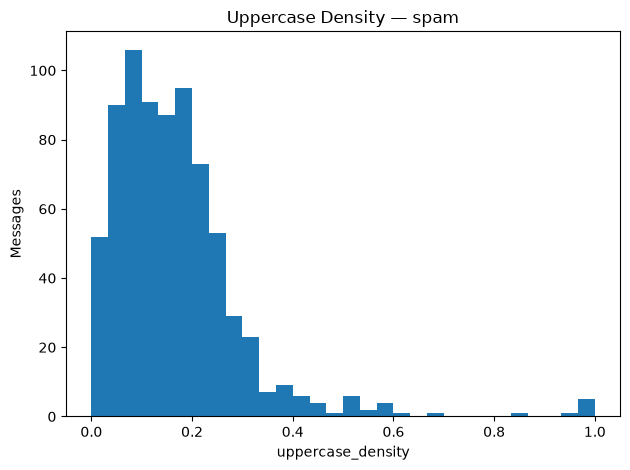

In [10]:
for column, title in [
    ("punctuation_density", "Punctuation Density"),
    ("digit_density", "Digit Density"),
    ("uppercase_density", "Uppercase Density"),
]:
    for label in ["ham", "spam"]:
        subset = df.loc[df["label"] == label, column]

        plt.figure()
        plt.hist(subset, bins=30)
        plt.title(f"{title} — {label}")
        plt.xlabel(column)
        plt.ylabel("Messages")
        plt.tight_layout()
        plt.show()


## 6. Non-ASCII / Unicode Inspection


In [11]:
unicode_counts = (
    df.groupby("label")["non_ascii_count"]
    .agg(["mean", "median", "max"])
)

unicode_counts


,mean,median,max
label,,,
ham,0.062358,0.0,4
spam,0.444444,0.0,4


In [12]:
non_ascii_examples = (
    df.loc[df["non_ascii_count"] > 0, ["label", "message", "non_ascii_count"]]
    .sort_values("non_ascii_count", ascending=False)
    .head(20)
)

non_ascii_examples


,label,message,non_ascii_count
555,ham,I‘ll have a look at the frying pan in case it‘...,4
4762,ham,It's é only $140 ard...É rest all ard $180 at ...,4
4147,ham,I cant wait for cornwall. Hope tonight isnt ...,4
4139,ham,"Good! No, don‘t need any receipts—well done! (...",4
2448,ham,Tmr then ü brin lar... Aiya later i come n c l...,4
1722,ham,Am watching house – very entertaining – am get...,4
5356,ham,Aiyo cos i sms ü then ü neva reply so i wait 4...,4
2791,spam,U’ve Bin Awarded £50 to Play 4 Instant Cash. C...,4
2572,ham,… and don‘t worry we‘ll have finished by march...,4
5004,spam,CDs 4u: Congratulations ur awarded £500 of CD ...,3


## 7. Candidate Preprocessing Questions

Use the measured results above to answer:

1. Should case be normalized?
2. Should punctuation be preserved?
3. Should digits be preserved?
4. Should non-ASCII characters be preserved?
5. Should whitespace be normalized?
6. Should URLs / phone numbers be specially normalized?
7. Should stopwords be removed?
8. How should duplicate messages influence train/test splitting?
9. Is character-level information potentially useful enough to investigate later?

The answers must be written in `docs/eda_report.md` with evidence from this notebook.
